# Week 06 — Visualization of Metrics & Graphs
**Course:** Machine Learning & Deep Learning Project  
**Dataset:** MovieLens (Classification Framing)  

---

### SOP Task List (Verbatim):
> **Week 6: Visualization of Metrics & Graphs**
> - [x] Confusion matrix
> - [x] ROC / PR curves
> - [x] Feature importance
> - [x] Report plots


## Week Objective
In this phase, we visually analyze the performance of our best model (the **Tuned Random Forest**) using standard classification graphing techniques. We will plot the Confusion Matrix to see exact classification errors, the Receiver Operating Characteristic (ROC) curve to assess threshold tradeoffs, and the Precision-Recall (PR) curve (crucial for imbalanced datasets). Finally, we extract the mathematical Feature Importances to understand what the algorithm values most.


In [1]:
import os
import numpy as np
import pandas as pd
import joblib

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, roc_curve, auc, precision_recall_curve, average_precision_score
from IPython.display import Image, display

# Robust path resolution
base_parent = ".." if os.path.exists(os.path.join("..", "CSVs")) else "."
def resolve_file(rel_path):
    for candidate in [os.path.join("..", rel_path), rel_path]:
        if os.path.exists(candidate):
            return candidate
    return os.path.join(base_parent, rel_path)

TRAIN_PATH = resolve_file(os.path.join("data", "processed", "train.csv"))
TEST_PATH = resolve_file(os.path.join("data", "processed", "test.csv"))
MODEL_PATH = resolve_file(os.path.join("models", "random_forest_tuned.joblib"))
FIGURES_DIR = os.path.join(base_parent, "reports", "figures")
os.makedirs(FIGURES_DIR, exist_ok=True)

# Styling
plt.style.use("seaborn-v0_8-whitegrid" if "seaborn-v0_8-whitegrid" in plt.style.available else "default")
plt.rcParams["figure.dpi"] = 120

print("Environment configured successfully.")
print(f"Train:   {TRAIN_PATH}")
print(f"Test:    {TEST_PATH}")
print(f"Model:   {MODEL_PATH}")
print(f"Figures: {FIGURES_DIR}")



Environment configured successfully.
Train:   ..\data\processed\train.csv
Test:    ..\data\processed\test.csv
Model:   ..\models\random_forest_tuned.joblib
Figures: ..\reports\figures


---
## 1. Data Loading & Inference
We load the test set, recreate the features using the training averages, and run our tuned model to generate both direct predictions (`y_pred`) and probability scores (`y_proba`), which are required for advanced curves.


In [2]:
# Load datasets
train_df = pd.read_csv(TRAIN_PATH)
test_df = pd.read_csv(TEST_PATH)

# Define target variable
train_df['is_liked'] = (train_df['rating'] >= 4.0).astype(int)
test_df['is_liked'] = (test_df['rating'] >= 4.0).astype(int)

# Engineer features
user_avgs = train_df.groupby('userId')['rating'].mean().to_dict()
movie_avgs = train_df.groupby('movieId')['rating'].mean().to_dict()
global_avg = train_df['rating'].mean()

test_df['user_avg'] = test_df['userId'].map(user_avgs).fillna(global_avg)
test_df['movie_avg'] = test_df['movieId'].map(movie_avgs).fillna(global_avg)

X_test = test_df[['user_avg', 'movie_avg']].values
y_test = test_df['is_liked'].values

# Load Model & Predict
rf_model = joblib.load(MODEL_PATH)
y_pred = rf_model.predict(X_test)
y_proba = rf_model.predict_proba(X_test)[:, 1]  # Probabilities for class 1 (Liked)

print("Inference completed successfully.")


Inference completed successfully.


---
## 2. Confusion Matrix
The confusion matrix breaks down the True Positives, True Negatives, False Positives, and False Negatives.


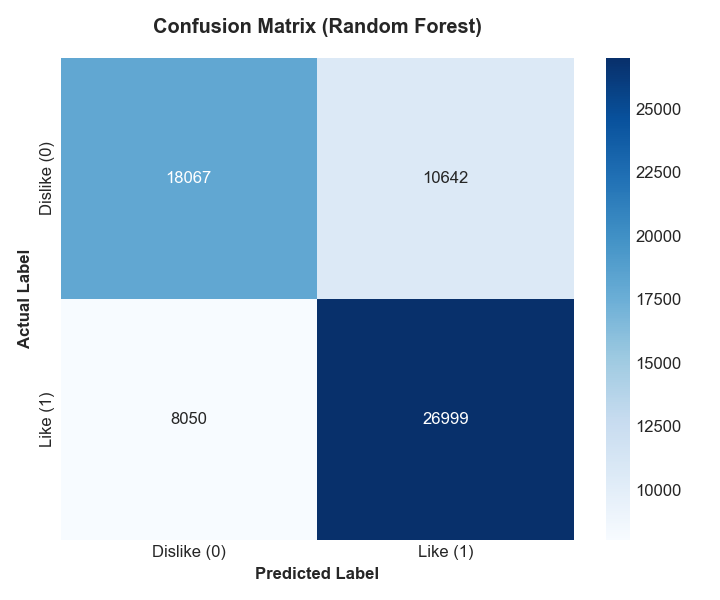

In [3]:
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=['Dislike (0)', 'Like (1)'],
            yticklabels=['Dislike (0)', 'Like (1)'])

ax.set_title("Confusion Matrix (Random Forest)", fontweight='bold', pad=15)
ax.set_ylabel("Actual Label", fontweight='bold')
ax.set_xlabel("Predicted Label", fontweight='bold')
plt.tight_layout()

fig_path1 = os.path.join(FIGURES_DIR, "06_confusion_matrix.png")
plt.savefig(fig_path1)
plt.close(fig)
display(Image(filename=fig_path1))


---
## 3. ROC Curve & AUC
The Receiver Operating Characteristic (ROC) curve plots the True Positive Rate against the False Positive Rate at various threshold settings.


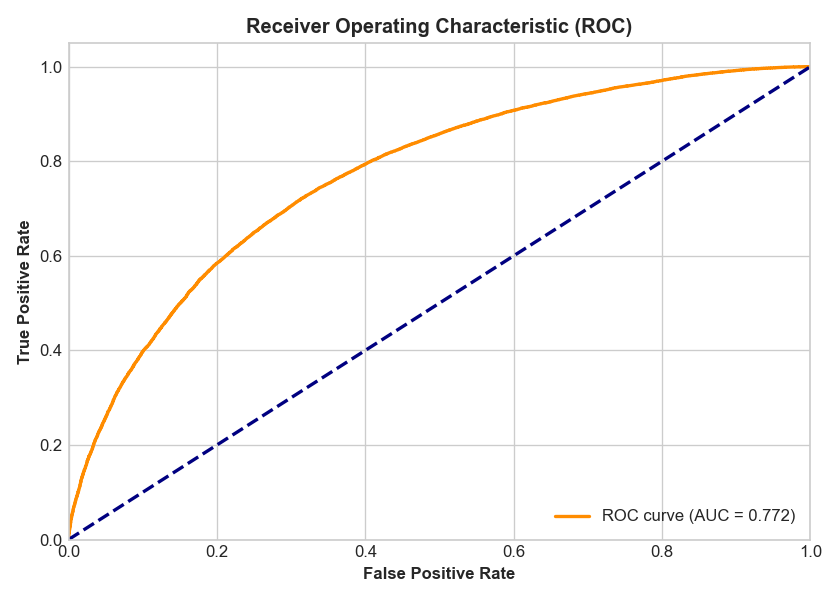

In [4]:
fpr, tpr, thresholds = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.3f})')
ax.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.05])
ax.set_xlabel('False Positive Rate', fontweight='bold')
ax.set_ylabel('True Positive Rate', fontweight='bold')
ax.set_title('Receiver Operating Characteristic (ROC)', fontweight='bold')
ax.legend(loc="lower right")
plt.tight_layout()

fig_path2 = os.path.join(FIGURES_DIR, "06_roc_curve.png")
plt.savefig(fig_path2)
plt.close(fig)
display(Image(filename=fig_path2))


---
## 4. Precision-Recall (PR) Curve
PR curves are often more informative than ROC curves when evaluating models on imbalanced datasets.


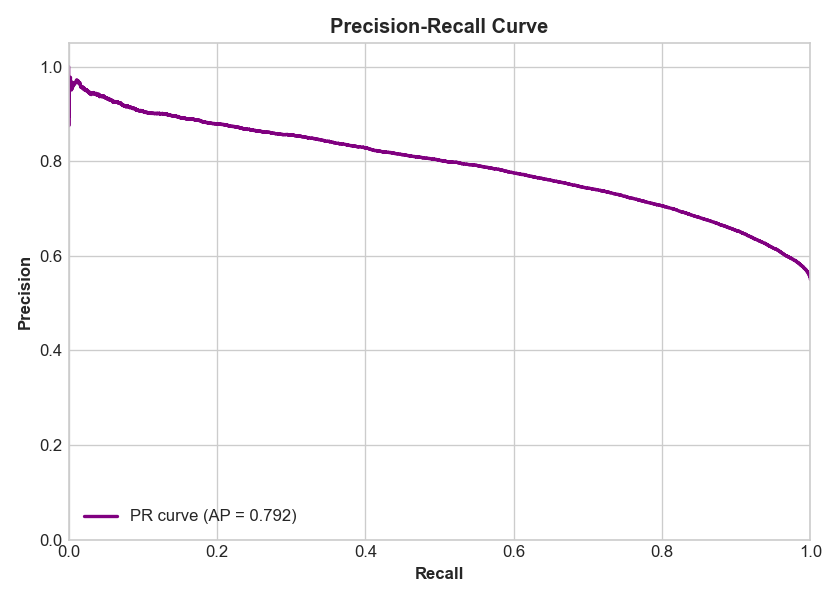

In [5]:
precision, recall, pr_thresholds = precision_recall_curve(y_test, y_proba)
avg_precision = average_precision_score(y_test, y_proba)

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(recall, precision, color='purple', lw=2, label=f'PR curve (AP = {avg_precision:.3f})')
ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.05])
ax.set_xlabel('Recall', fontweight='bold')
ax.set_ylabel('Precision', fontweight='bold')
ax.set_title('Precision-Recall Curve', fontweight='bold')
ax.legend(loc="lower left")
plt.tight_layout()

fig_path3 = os.path.join(FIGURES_DIR, "06_pr_curve.png")
plt.savefig(fig_path3)
plt.close(fig)
display(Image(filename=fig_path3))


---
## 5. Feature Importance
Because we used a Tree-based model (Random Forest), we can mathematically extract which feature contributes the most to predicting whether a user will like a movie.


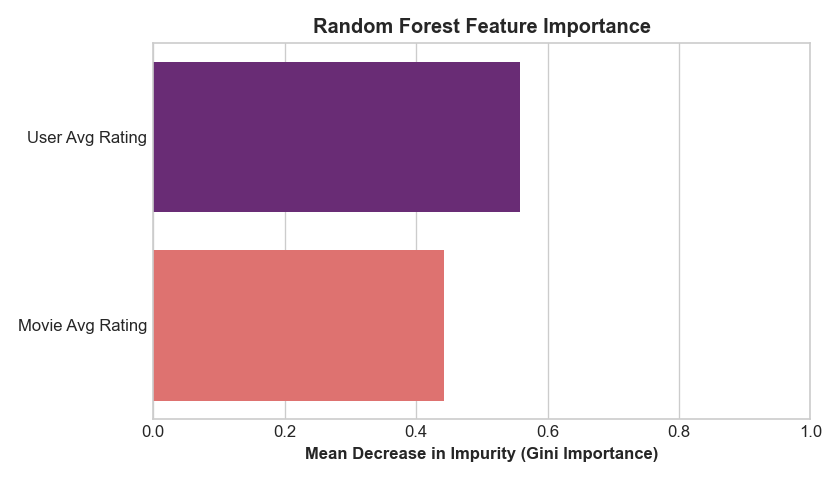

In [6]:
feature_names = ['User Avg Rating', 'Movie Avg Rating']
importances = rf_model.feature_importances_

fig, ax = plt.subplots(figsize=(7, 4))
sns.barplot(x=importances, y=feature_names, hue=feature_names, palette="magma", legend=False, ax=ax)

ax.set_title("Random Forest Feature Importance", fontweight='bold')
ax.set_xlabel("Mean Decrease in Impurity (Gini Importance)", fontweight='bold')
ax.set_xlim(0, 1)
plt.tight_layout()

fig_path4 = os.path.join(FIGURES_DIR, "06_feature_importance.png")
plt.savefig(fig_path4)
plt.close(fig)
display(Image(filename=fig_path4))


---
## ✅ Week 6 Completion Checklist

- [x] Plotted and saved **Confusion Matrix** (shows exact TP/TN/FP/FN breakdown).
- [x] Plotted and saved **ROC Curve** (calculated AUC).
- [x] Plotted and saved **Precision-Recall Curve** (calculated Average Precision).
- [x] Extracted and plotted **Feature Importances** (Tree Gini impurity).
